## Imports

In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d

In [2]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

### Functions

In [3]:
def get_radial_profile(frank_object,  n_bins, range_):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    r = np.hypot(x, y)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned


def get_radial_profile_deprojected(frank_object, n_bins, range):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = (frank_object._Geometry._pa- 90)*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)


    x_d = (x * cos_pa + y * sin_pa) / cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    
    r = np.hypot(x_d, y_d)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = n_bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned

In [4]:
def get_vis_profile(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn
    pixel_size = (u[1]-u[0])
    q = np.hypot(u, v)
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    if range is None:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins)
    else:
        Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned


def get_vis_profile_deprojected(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    u_ = u * cos_pa - v * sin_pa
    v_d = u * sin_pa + v * cos_pa
    u_d = u_ * cos_i
    
    q = np.hypot(u_d, v_d)
    
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
            
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

In [5]:
def deproject(u, v, inc, pa, inverse=False):  
    inc *= const.deg_to_rad
    pa *= const.deg_to_rad

    cos_t = np.cos(pa)
    sin_t = np.sin(pa)

    if inverse:
        sin_t *= -1
        u = u / np.cos(inc)

    up = u * cos_t - v * sin_t
    vp = u * sin_t + v * cos_t

    if inverse:
        return up, vp
    else:
    #   Deproject
        wp = up * np.sin(inc)
        up = up * np.cos(inc)

        return up, vp

def deproject_real_space(frank_object):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec
    
    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    x_d = (x * cos_pa + y * sin_pa)/cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    return x_d, y_d

In [6]:
def sweep_profile(r, I, project=False, phase_shift=False, geom=None, axis=0,
                  xmax=None, ymax=None, dr=None, deproject = False ):
    if project or deproject:
        inc, pa = geom['inc'], geom['pa']
        inc *= constants.deg_to_rad
        pa *= constants.deg_to_rad

        cos_i = np.cos(inc)
        cos_pa, sin_pa = np.cos(pa), np.sin(pa)

    if xmax is None:
        xmax = r.max()
    if ymax is None:
        ymax = r.max()

    if dr is None:
        dr = np.mean(np.diff(r))

    x = np.linspace(-xmax, xmax, int(xmax/dr))
    y = np.linspace(-ymax, ymax, int(ymax/dr))
    print(len(x))

    if phase_shift:
        xi, yi = np.meshgrid(x + geom['dra'], y - geom['ddec'])
    else:
        xi, yi = np.meshgrid(x, y)

    if project:
        xp  = xi * cos_pa + yi * sin_pa
        yp  = -xi * sin_pa + yi * cos_pa
        xp /= cos_i
        r1D = np.hypot(xp, yp)
    elif deproject:
        xp = xi * cos_i
        x_unrot = xp * cos_pa - yi * sin_pa
        y_unrot = xp * sin_pa + yi * cos_pa
        r1D = np.hypot(x_unrot, y_unrot)
    else:
        r1D = np.hypot(xi, yi)

    im_shape = r1D.shape + I.shape[1:]
    print(im_shape)

    interp = interp1d(r, I, bounds_error=False, fill_value=0., axis=axis)
    I2D = interp(r1D.ravel()).reshape(*im_shape)

    return I2D, xmax, ymax

### Data

In [107]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "../../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

In [8]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
u_deproj, v_deproj, vis_deproj = geom.apply_correction(u, v, Vis)

### Let's see the gridded visibilities

In [9]:
N = 300

In [10]:
m, c, l = -0.33, -0.1, 1e5

In [11]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

In [12]:
frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= False)

  --> time = 0.00  min |  0.27 seconds
Setting gridded data...


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


In [13]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [14]:
FT = frank2d._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):d}" if abs(x) > 1e-8 else "0"

#### Plots

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5749/2364485543.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


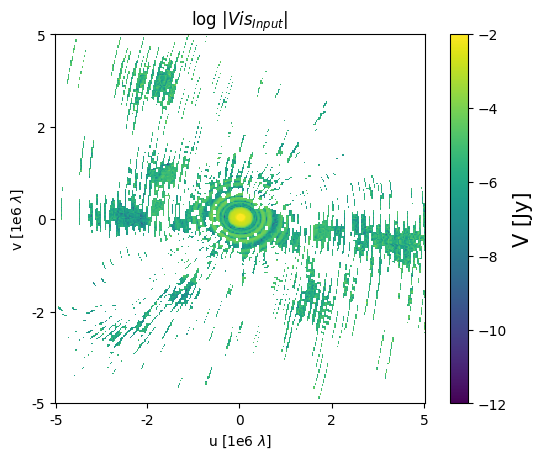

In [15]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [16]:
frank2d.frank1d(u, v, Vis, Weights)

In [17]:
vis_f1d = frank2d._frank1d_guess

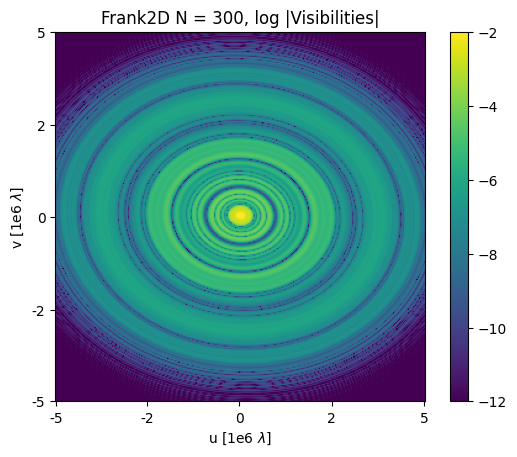

In [18]:
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_f1d).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(F'Frank2D N = {N}, log |Visibilities|')
plt.colorbar()

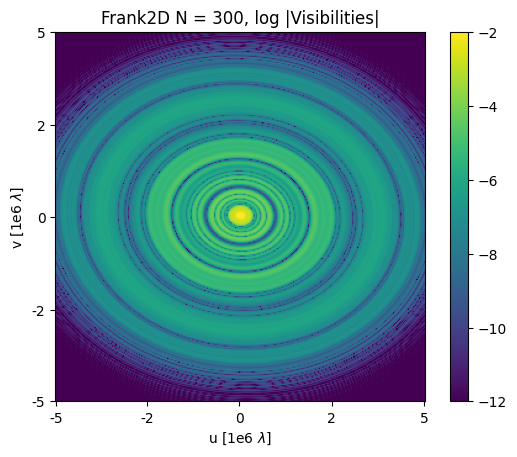

In [19]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_f1d.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(F'Frank2D N = {N}, log |Visibilities|')
plt.colorbar()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5749/489374839.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift((vis_gridded).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


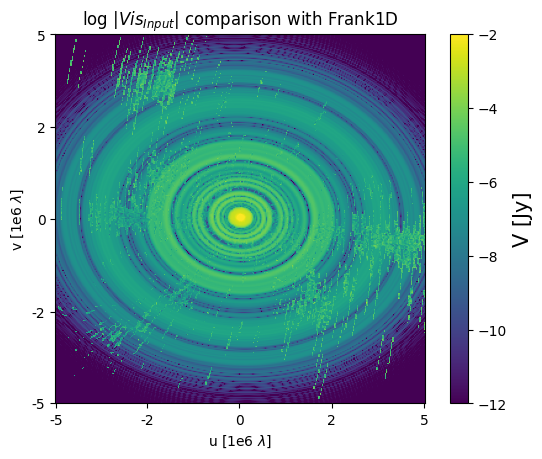

In [20]:
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_f1d).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.imshow(np.log(np.abs(np.fft.fftshift((vis_gridded).reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$| comparison with Frank1D')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

### Running F2D

In [21]:
N = 250
m, c, l = -0.33, -0.1, 1e5


In [22]:
Routs = [1.5, 2, 2.5, 3, 4] 

### Projected scheme

In [23]:
import pickle


def run_frank2d(N, R_out, inc, pa, dra, ddec):
    start_time = time.time()
    #-------------------------------------------------------------------------------------------    
    frank2d = Frank2D(N, R_out, Geometry(inc, pa, dra, ddec))
    frank2d.set_kernel('Wendland', [m, c, l])
    frank2d.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15, frank1d_guess = False)
    

    #-------------------------------------------------------------------------------------------
    print("--------------------------------------")
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

    file_name =  "frank2d_l1e5_N" + str(N) + "_Rout" + str(R_out)
    
    with open(file_name +'.pkl', 'wb') as f: 
        pickle.dump(frank2d.sol_visibility, f) 

    return frank2d
            

In [24]:
frank2d_array = []
for i in Routs:
    print("Running... Rout = " + str(i))
    frank2d_array.append(run_frank2d(N, i, inc, pa, dra, ddec))

Running... Rout = 1.5
Setting kernel: Wendland...
Gridding...


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


  --> time = 0.02  min |  1.10 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...
Setting A...
Setting A_precond...
Setting b...
     --> time = 2.07  min |  124.35 seconds
  *  Solving linear system...
     * BICGSTAB
         * rtol: 1e-15
         * final tolerance: 2.4192927818844882e-08
         * maxiter:  625000
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteration:  16
             .. iteration:  17
             .. iteration:  18
  

## Frank1d

In [25]:
# Frank 1D Parameters
n_pts = 300
alpha = 1.3
w_smooth = 1e-3

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(Rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u, v, Vis, Weights)

## Comparison with Frank1D

### Fourier space

In [26]:
u_gridded_d, v_gridded_d, _= Geometry(inc, pa, dra, ddec).deproject(u_gridded, v_gridded)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5749/3671317330.py:63: RuntimeWarning: invalid value encountered in divide
  return q_centers, Vis_Weights_binned/Weights_binned


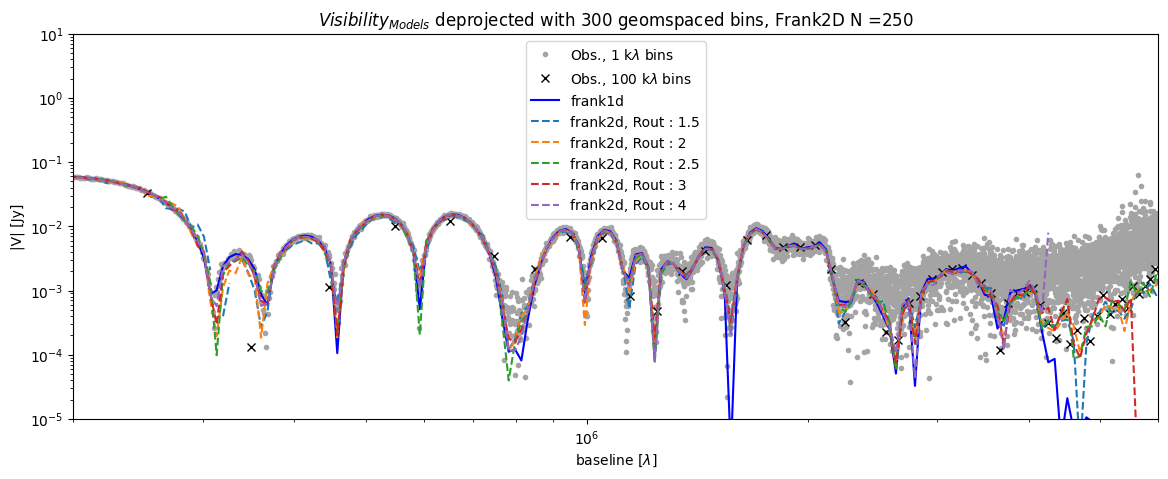

In [27]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# --------------------------LOG BINS----------------------------------------------------------
#frank1d
Nbins = 300
baselines_edges = np.geomspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------

c = 0
for i in frank2d_array:
    #frank2d deprojected
    q, Vis_d = get_vis_profile_deprojected(i, baselines_edges, range, weighted = True)
    plt.plot(baselines_centers, np.abs(Vis_d), label = f'frank2d, Rout : '+ str(Routs[c]),ls='--')
    c+=1

# ---------------------------------------------------------------------------------------------
# Gridded visibilities
#baselines_gridded_d = np.hypot(u_gridded_d, v_gridded_d)  
#binned_vis_gridded = UVDataBinner(baselines_gridded_d, vis_gridded, weights_gridded, bin_widths[1])
#plt.plot(binned_vis_gridded.uv, np.abs(binned_vis_gridded.V), c='red',
#             marker=ms[1], ls='None', 
#             label=r'Gridded input: {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 10)
plt.xlim(2e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(Nbins) + ' geomspaced bins, Frank2D N =' + str(N))
plt.legend(fontsize= 10, loc = 'best')
plt.show()

In [28]:
int(len(frank2d_array))

5

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5749/3671317330.py:63: RuntimeWarning: invalid value encountered in divide
  return q_centers, Vis_Weights_binned/Weights_binned


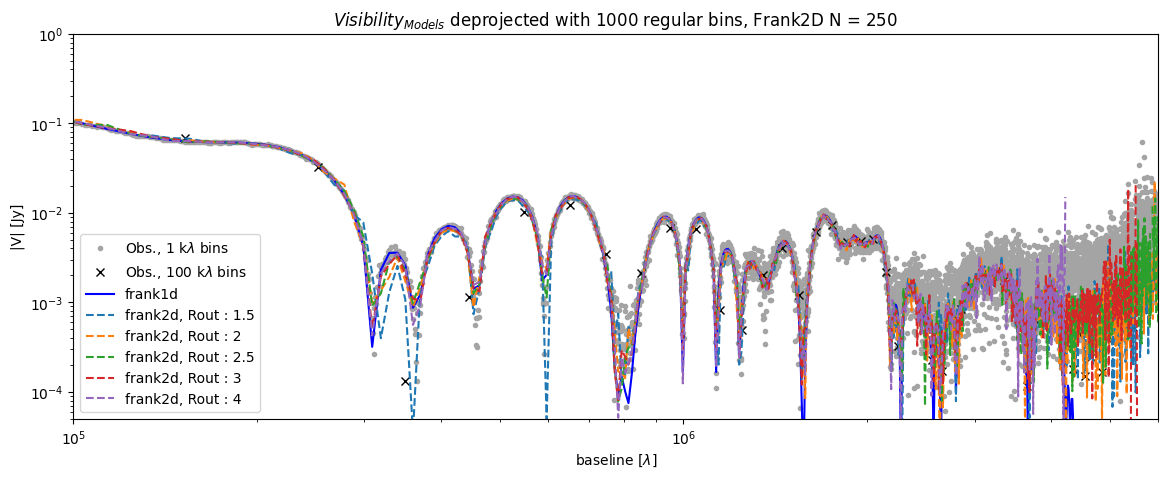

In [29]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# -----------------LINSPACE BINS--------------------------------------------------------------
#frank1d
Nbins = 1000
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = baselines_edges[:-1] + (baselines_edges[1] - baselines_edges[0])/2
range = (sol.q[0], sol.q[-1])

vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------
c = 0
for i in frank2d_array:
    #frank2d deprojected
    q, Vis_d = get_vis_profile_deprojected(i, Nbins, range, weighted = True)
    plt.plot(baselines_centers, np.abs(Vis_d), label = f'frank2d, Rout : '+ str(Routs[c]),ls='--')
    c+=1


# ---------------------------------------------------------------------------------------------
# Gridded visibilities
#baselines_gridded_d = np.hypot(u_gridded_d, v_gridded_d)  
#binned_vis_gridded = UVDataBinner(baselines_gridded_d, vis_gridded, weights_gridded, bin_widths[1])
#plt.plot(binned_vis_gridded.uv, np.abs(binned_vis_gridded.V), c='red',
#             marker=ms[1], ls='None', 
#             label=r'Gridded input: {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(0.5e-4, 1)
plt.xlim(1e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(Nbins) + ' regular bins, Frank2D N = ' + str(N))
plt.legend(fontsize= 10)
plt.show()

### Real space

In [215]:
cos_i =  np.cos(frank2d._Geometry._inc*deg_to_rad)

In [216]:
dr = (sol.r[1] - sol.r[0])/2
bin_edges = np.concatenate((sol.r - dr, [sol.r[-1] + dr]))

In [224]:
print(frank2d_array[0].sol_intensity)

None


Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds


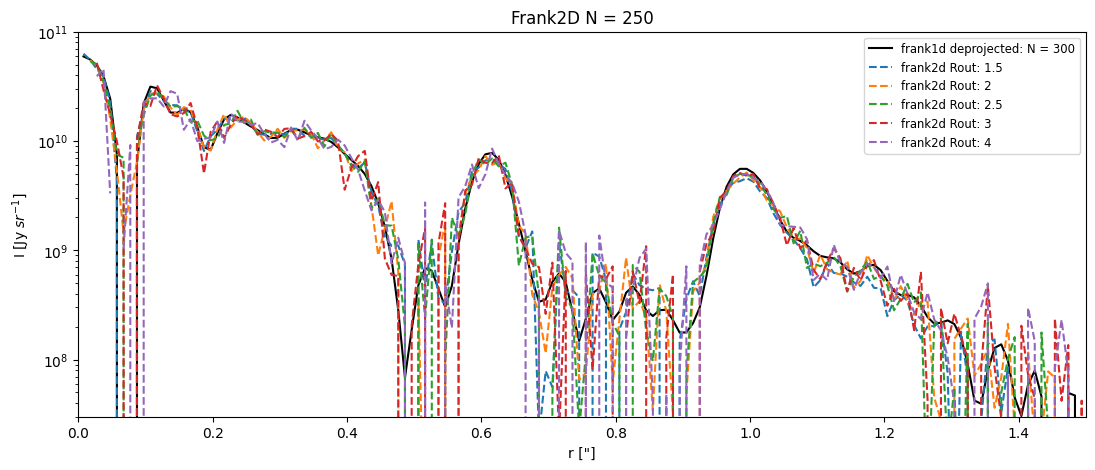

In [233]:
plt.figure(figsize=(13,5))
plt.plot(sol.r, sol.mean, 'black',label =f'frank1d deprojected: N = {n_pts}')

c = 0
for i in frank2d_array:
    i.fft()
    r_f2d_projected_d, I_f2d_projected_d = get_radial_profile_deprojected(i, bin_edges, (sol.r[0], sol.r[-1]))
    plt.plot(sol.r, I_f2d_projected_d, label = r'frank2d Rout: ' + str(Routs[c]), ls='--')
    c+=1
plt.xlabel('r ["]')
plt.xlim(0,1.5)      
plt.ylim(3e7, 1e11)
plt.ylabel(r'I [Jy $sr^{-1}$]')
plt.legend(fontsize = 'small')
plt.title('Frank2D N = '+ str(N))
plt.yscale("log")
plt.show()

## Comparing with CLEAN

In [234]:
# Obtain the radial profiles convolved to a circular beam.
from gofish import imagecube

infile_1mm = dir + 'AS209_1mm_13s_conv_circ.fits'
#2D->1D
cube_1mm = imagecube(infile_1mm)
x_1mm,y_1mm,dy_1mm = cube_1mm.radial_profile(inc=inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [235]:
from frank.utilities import convolve_profile

clean_beam_1mm = {'bmaj':0.0373, 'bmin':0.0373, 'beam_pa':31.040}
area_1mm = clean_beam_1mm['bmaj']*clean_beam_1mm['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

convolved_1mm_frank1d = convolve_profile(sol.r, sol.mean, inc, pa, clean_beam_1mm)*area_1mm

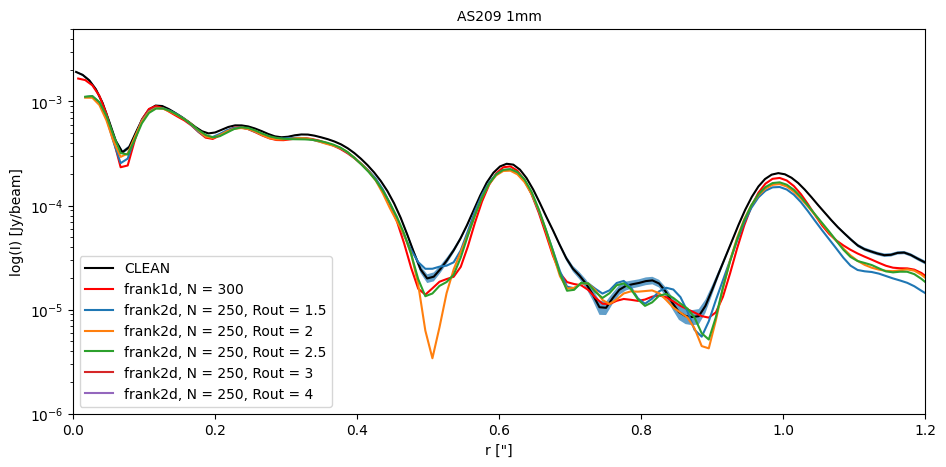

In [240]:
plt.figure(figsize=(11, 5))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(sol.r, convolved_1mm_frank1d, "red", label=r'frank1d' + ', N = ' +str(n_pts))

c = 0
for i in frank2d_array:
    r_f2d_projected_d, I_f2d_projected_d = get_radial_profile_deprojected(i, bin_edges, (sol.r[0], sol.r[-1]))
    convolved_1mm_frank2d = convolve_profile(r_f2d_projected_d[1:], I_f2d_projected_d[1:], inc, pa, clean_beam_1mm)*area_1mm
    if c == 2:
        plt.plot(sol.r[1:],convolved_1mm_frank2d,  label=r'frank2d' + ', N = ' +str(N) + ', Rout = ' + str(Routs[c]), ls= ':')
    if c == 3:
        plt.plot(sol.r[1:],convolved_1mm_frank2d,  label=r'frank2d' + ', N = ' +str(N) + ', Rout = ' + str(Routs[c]), ls = '--')
    c+=1
plt.title(disk_name, size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=10)
plt.yscale('log')
plt.ylim(0.1e-5, 0.5e-2)
plt.xlim(0,1.2)
plt.show()

### Let's improve plot class

In [375]:
class Plot():
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._Nx = Frank2D._Nx
        self._Ny = Frank2D._Ny

        
    def intensity_model(self, title="Frank2D intensity model", deproject = False, fig_size = 7):
        frank2d = self._frank2d
        I = frank2d.sol_intensity
        x_ = frank2d._FT._Xn * rad_to_arcsec
        y_ = frank2d._FT._Yn * rad_to_arcsec
        Nx, Ny = self._Nx, self._Ny
        x, y = x_, y_

        inc_r = self._Geometry._inc * deg_to_rad
        pa_r = self._Geometry._pa * deg_to_rad

        cos_i = np.cos(inc_r)
        cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
        if deproject:
            x = (x_ * cos_pa + y_ * sin_pa) / cos_i
            y = (x_ * -sin_pa + y_ * cos_pa)

        plt.figure(figsize=(fig_size, fig_size))

        plot = plt.pcolormesh(y.reshape(Nx, Ny), x.reshape(Nx, Ny), I.reshape(Nx, Ny),
                              cmap='magma', vmin=0, vmax=4e10)
        plt.gca().invert_xaxis()
        cmap = plt.colorbar(plot)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=15)

        plt.title(title)
        plt.xlabel("dRa ['']")
        plt.ylabel("dDec ['']")

        # Asegurar misma cantidad de elementos en ambos ejes
        plt.gca().set_aspect(1)  # Fija la relación de aspecto a 1:1

        xlim = plt.xlim()
        ylim = plt.ylim()
        
        # Forzar límites iguales en ambos ejes para evitar distorsión
        lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
        plt.xlim(lims)
        plt.ylim(lims)

        plt.text(
            lims[0] + 0.1 * (lims[1] - lims[0]),  
            lims[0] + 0.1 * (lims[1] - lims[0]),  
            r'  $N^{2}$ pixels,  N = ' + str(Nx) + '  ',
            bbox={'facecolor': 'white', 'pad': 4, 'alpha': 0.8}
        )

        plt.show()


    def visibility_model(self, title="Frank2D visibility model", deproject = False, fig_size = 7):
            frank2d = self._frank2d
            vis_model = frank2d.sol_visibility.reshape(N, N)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            Nx, Ny = self._Nx, self._Ny

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_sol)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            plt.pcolormesh(v_shifted.reshape(Nx, Ny), u_shifted.reshape(Nx, Ny), np.log(np.abs(vis_shifted)), cmap="viridis", vmin=-12, vmax=-2)
            plt.xlabel(r'u [ $\lambda$]')
            plt.ylabel(r'v [ $\lambda$]')
            plt.gca().set_aspect('equal') 
            cmap = plt.colorbar()
            cmap.set_label(r'V [Jy]', size=15)
            plt.title(r'log|$Vis_{model}$|')
            plt.show()


    def visibility_gridded_input(self, title="Frank2D gridded input", fig_size = 7):
        frank2d = self._frank2d
        u_gridded, v_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v']
        vis_gridded, weights_gridded = frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

        FT = frank2d._FT
        x_labels = np.fft.fftshift(FT._u/1e6)
        y_labels = np.fft.fftshift(FT._v/1e6)

        num_ticks = 5
        x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
        y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

        def format_labels(x):
            return f"{int(x):d}" if abs(x) > 1e-8 else "0"
        
        plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(self._Nx, self._Ny)))), origin='lower', vmin=-12, vmax=-2)
        plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
        plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'log |$Vis_{Input}$|')
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)


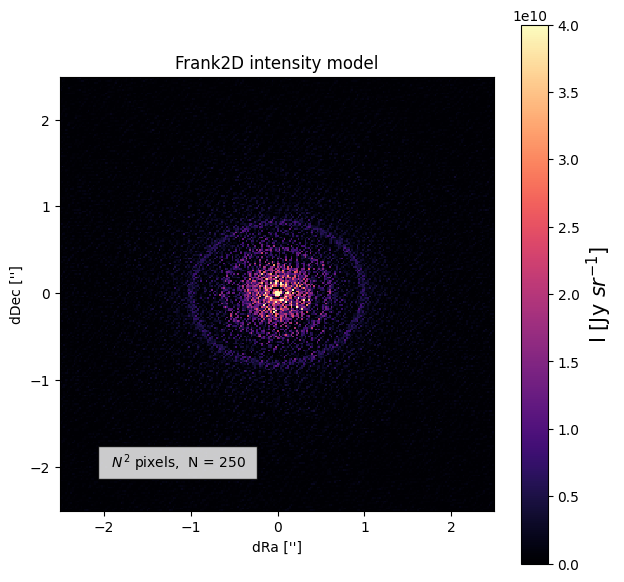

In [378]:
Plot(frank2d_array[2], Geometry(inc, pa, dra, ddec)).intensity_model(fig_size = 7, deproject = False)

### Let's see how the model in long baselines affect

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5749/3671317330.py:63: RuntimeWarning: invalid value encountered in divide
  return q_centers, Vis_Weights_binned/Weights_binned


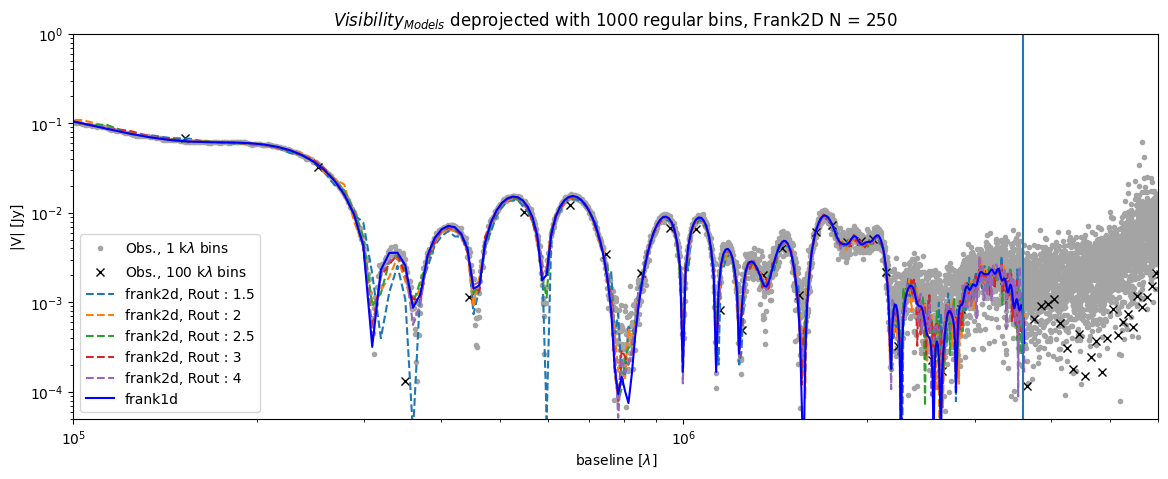

In [57]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# -----------------LINSPACE BINS--------------------------------------------------------------
Nbins = 1000
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = baselines_edges[:-1] + (baselines_edges[1] - baselines_edges[0])/2
range = (sol.q[0], sol.q[-1])

#frank2d -------------------------------------------------------------
c = 0
for i in frank2d_array:
    #frank2d deprojected
    q, Vis_d = get_vis_profile_deprojected(i, Nbins, range, weighted = True)
    plt.plot(baselines_centers[:lim], np.abs(Vis_d)[:lim], label = f'frank2d, Rout : '+ str(Routs[c]),ls='--')
    c+=1


#frank1d -------------------------------------------------------------
vis_fit_1d = sol.predict_deprojected(baselines_centers)
lim = 350
x_f1d = baselines_centers[:lim]
y_f1d = np.abs(vis_fit_1d)[:lim]
plt.plot(x_f1d, y_f1d, color = "blue", label = r'frank1d')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(0.5e-4, 1)
plt.xlim(1e5, 6e6)
plt.axvline(3.6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(Nbins) + ' regular bins, Frank2D N = ' + str(N))
plt.legend(fontsize= 10)
plt.show()